CSV loaded successfully!
Summary statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.00000,517860.000000,517860.000000,517860.000000,517860.000000,0.0
mean,236.234508,166.896673,111.656477,232.393310,225.026584,28.146975,54.574586,2.065886,2.737151,0.465109,153.570868,8.526833,994.18638,0.000935,0.001123,35.085631,32.371906,NaN
std,328.288787,262.081997,153.099749,324.256767,314.315996,5.924507,28.010491,1.513137,1.907636,0.260157,102.692758,6.391820,2.46835,0.030557,0.022703,14.738292,12.334820,NaN
min,-11.100000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.00000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,29.000000,0.900000,1.300000,0.400000,58.200000,3.600000,993.00000,0.000000,0.000000,24.200000,23.500000,NaN
50%,0.700000,-0.100000,0.500000,3.400000,3.200000,27.900000,55.100000,1.900000,2.400000,0.500000,182.300000,8.600000,994.00000,0.000000,0.000000,29.800000,28.800000,NaN
75%,468.700000,316.300000,212.000000,448.700000,434.000000,32.300000,80.100000,3.000000,3.900000,0.600000,235.300000,12.200000,996.00000,0.000000,0.000000,46.500000,41.300000,NaN
max,1233.000000,952.300000,591.400000,1205.100000,1175.000000,43.800000,100.000000,6.900000,8.700000,2.300000,360.000000,99.400000,1003.00000,1.000000,2.300000,81.000000,72.500000,NaN



Missing values per column:


Comments    517860
dtype: int64

Outliers detected: 3006 rows


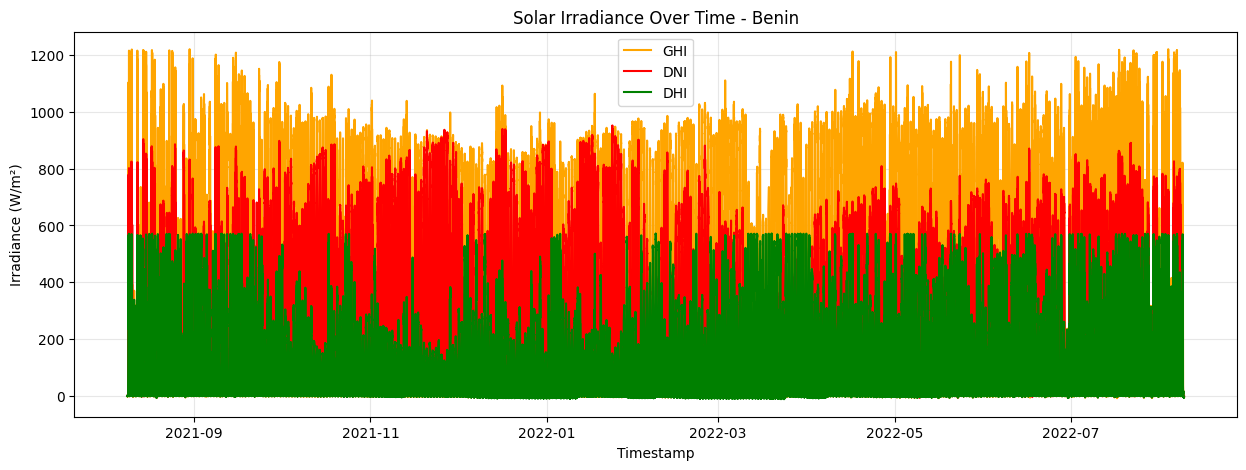

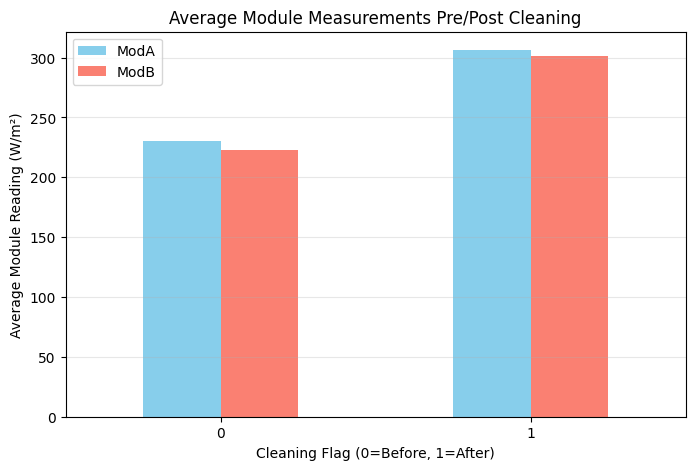

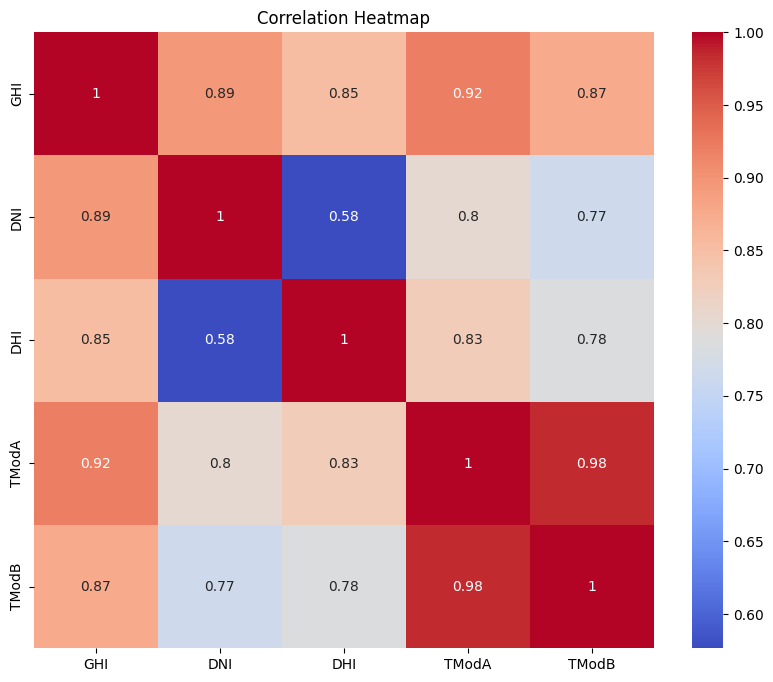

c:\Users\hamar\Downloads\solar\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


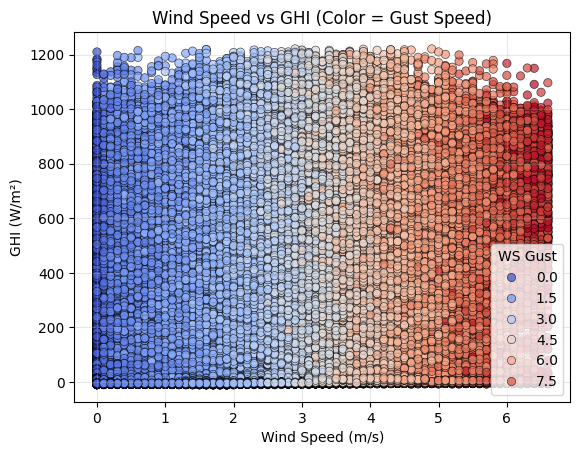

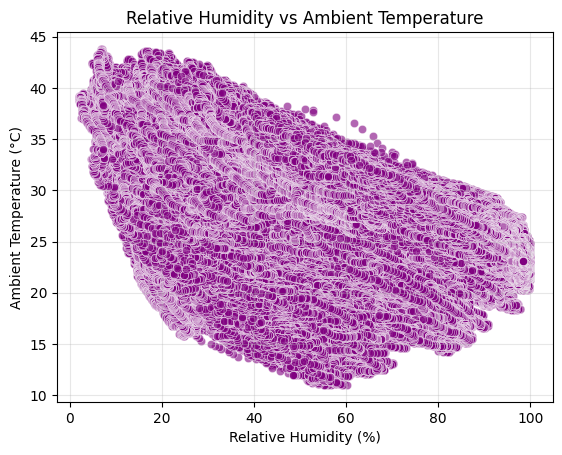

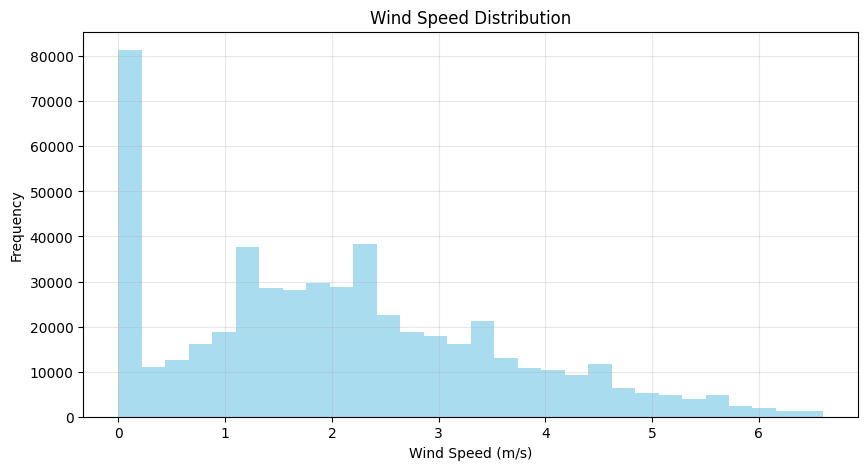

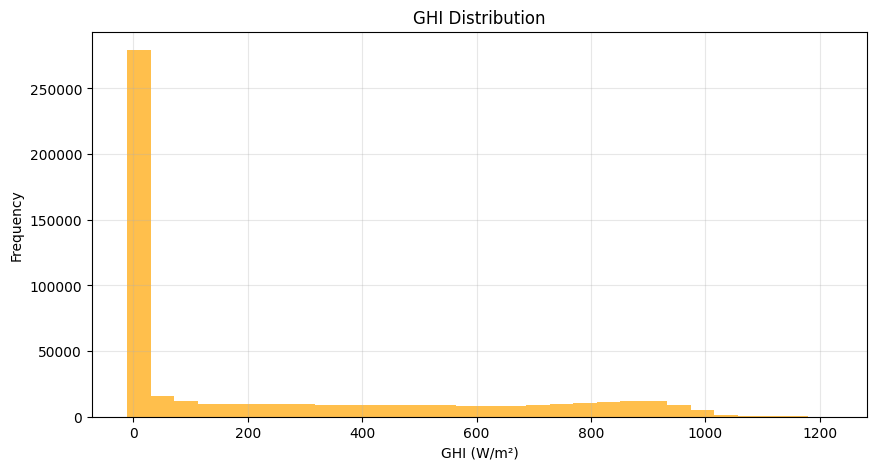

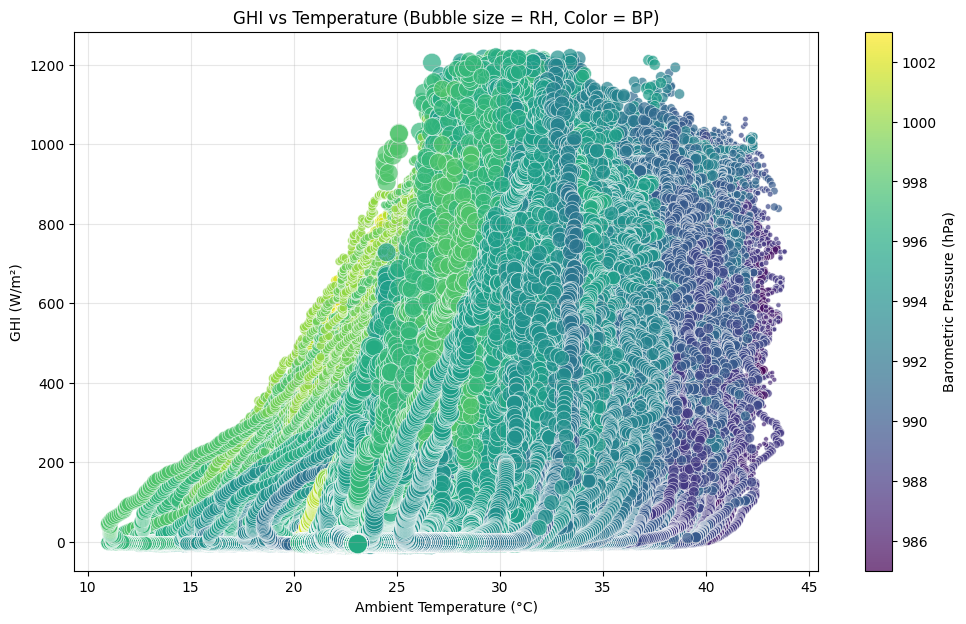

Cleaned dataset saved to ../data/benin_clean.csv


In [1]:
# ===============================
# Benin Solar Data: EDA & Cleaning
# ===============================

# Import libraries
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -------------------------------
# 1. Load dataset robustly
# -------------------------------
path = "../data/benin-malanville.csv"  # Corrected path for your structure

if not os.path.exists(path):
    print(f"File not found at {path}")
    print("Current working directory:", os.getcwd())
    print("Top-level files:", os.listdir("."))
    
    if os.path.isdir("../data"):
        print("Files in data/:", os.listdir("../data"))
    
    # try to find any matching file recursively
    candidates = glob.glob("**/benin*.csv", recursive=True)
    if candidates:
        print("Found candidate(s):", candidates)
        path = candidates[0]
        print("Using:", path)
    else:
        raise FileNotFoundError(
            f"Could not find 'benin-malanville.csv'. Looked at {os.path.abspath('../data')} and recursive search."
        )

# Load CSV
df = pd.read_csv(path)
print("CSV loaded successfully!")
df.head()

# -------------------------------
# 2. Summary Statistics & Missing Values
# -------------------------------
print("Summary statistics:")
display(df.describe())

print("\nMissing values per column:")
missing_report = df.isna().sum()
display(missing_report[missing_report > 0])

# -------------------------------
# 3. Outlier Detection & Cleaning
# -------------------------------
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"Outliers detected: {outlier_mask.sum()} rows")

# Copy for cleaning
df_clean = df.copy()

# Impute missing values with median
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Remove outliers
df_clean = df_clean[~outlier_mask]

# -------------------------------
# 4. Time Series Analysis
# -------------------------------
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
plt.figure(figsize=(15,5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI', color='orange')
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI', color='red')
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI', color='green')
plt.xlabel("Timestamp")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance Over Time - Benin")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 5. Cleaning Impact
# -------------------------------
avg_mod_cleaning = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
avg_mod_cleaning.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Module Measurements Pre/Post Cleaning',
    color=['skyblue', 'salmon']
)
plt.ylabel("Average Module Reading (W/m²)")
plt.xlabel("Cleaning Flag (0=Before, 1=After)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# -------------------------------
# 6. Correlation & Relationships
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(
    data=df_clean,
    x='WS',
    y='GHI',
    hue='WSgust',
    palette='coolwarm',
    alpha=0.7,
    edgecolor='k'
)
plt.title("Wind Speed vs GHI (Color = Gust Speed)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("GHI (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend(title='WS Gust')
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb', color='purple', alpha=0.6)
plt.title("Relative Humidity vs Ambient Temperature")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 7. Wind & Distribution Analysis
# -------------------------------
plt.figure(figsize=(10,5))
plt.hist(df_clean['WS'], bins=30, alpha=0.7, color='skyblue')
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_clean['GHI'], bins=30, alpha=0.7, color='orange')
plt.title("GHI Distribution")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 8. Bubble Chart: GHI vs Tamb with RH
# -------------------------------
plt.figure(figsize=(12,7))
scatter = plt.scatter(
    df_clean['Tamb'],       # x-axis: ambient temperature
    df_clean['GHI'],        # y-axis: GHI
    s=df_clean['RH']*2,     # bubble size proportional to RH
    c=df_clean['BP'],       # color based on barometric pressure
    cmap='viridis',         # color map
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)
plt.colorbar(scatter, label='Barometric Pressure (hPa)')
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title("GHI vs Temperature (Bubble size = RH, Color = BP)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 9. Export Cleaned Data
# -------------------------------
output_path = "../data/benin_clean.csv"
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")
